In [1]:
import pandas as pd
import numpy as np
import requests  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
def get_live_data(symbol='BTCUSDT', interval='1d', limit=500):
    url = f"https://api.binance.com/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}"
    data = requests.get(url).json()

In [4]:
def get_live_data(symbol='BTCUSDT', interval='1d', limit=500):
    url = f"https://api.binance.com/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}"
    data = requests.get(url).json()
    
    df = pd.DataFrame(data, columns=[
        'Open_Time', 'Open', 'High', 'Low', 'Close', 'Volume', 
        'Close_Time', 'Quote_Asset_Volume', 'Number_of_Trades', 
        'Taker_Buy_Base_Asset_Volume', 'Taker_Buy_Quote_Asset_Volume', 'Ignore'
    ])
    
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].astype(float)
    return df

df = get_live_data()
print("Live Data Fetched Successfully!")
print(df.tail())

Live Data Fetched Successfully!
         Open      High       Low     Close       Volume
495  88620.79  88940.00  86601.90  87486.00  13910.32904
496  87486.00  88049.89  86420.00  87669.45   9140.84320
497  87669.44  88592.74  86934.72  87225.27   7096.58235
498  87225.27  89567.75  86655.08  87369.56  18344.61505
499  87369.56  87702.00  87253.05  87634.40   3742.51712


In [5]:
df['MA7'] = df['Close'].rolling(window=7).mean()   # 7 din ka average
df['MA21'] = df['Close'].rolling(window=21).mean() # 21 din ka average
df['Price_Change'] = df['Close'].pct_change()     # Price kitni badli

df.dropna(inplace=True)

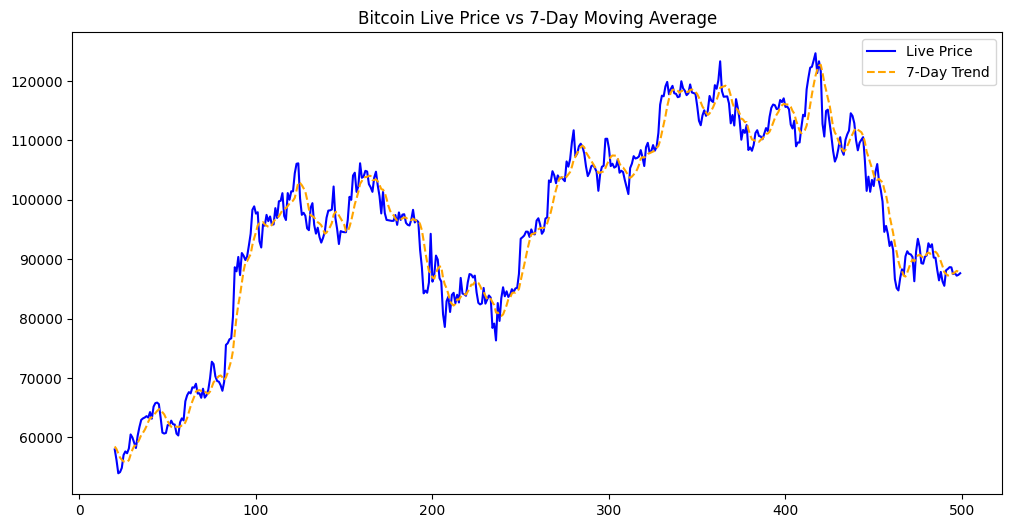

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Live Price', color='blue')
plt.plot(df['MA7'], label='7-Day Trend', linestyle='--', color='orange')
plt.title('Bitcoin Live Price vs 7-Day Moving Average')
plt.legend()
plt.show()

In [7]:
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA21']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Accuracy check karna
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)
print(f"Average Prediction Error: ${error:.2f}")

Average Prediction Error: $1888.81
